In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
import lazypredict
from lazypredict.Supervised import LazyRegressor
from sklearn.neural_network import MLPRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

c:\Users\admin\navigator\lib\site-packages\scipy\__init__.py:143: UserWarning: A NumPy version >=1.19.5 and <1.27.0 is required for this version of SciPy (detected version 2.2.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\admin\navigator\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\admin\navigator\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\admin\navigator\lib\site-package

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
# Load the dataset
try:
    df = pd.read_excel("Random Price Dataset Trial Assignment.xlsx", sheet_name="Raw data")
except FileNotFoundError:
    print("Error: The file 'Random-Price-Dataset-Trial-Assignment.xlsx' was not found. Make sure the file is in the correct directory.")
    exit()

In [ ]:
df.head()

,Date,"Domestic Market (Contract) Blow Molding, Low",Spot/Export Blow Molding,"Spot, Domestic",WTISPLC,MCOILBRENTEU,GASREGM,IMPCH,EXPCH,PRUBBUSDM,...,Russia_import,South_Africa_import,Turkey_import,Brazil_import,France_import,Germeny_import,United Kingdome_import,China_import,Japan_import,South_korea_import
0,2000-01-01,41.00,NaN,NaN,27.18,25.51,1.29,6902.10,863.10,29.21,...,NaN,NaN,6833222.00,2649293.00,35239920.00,NaN,NaN,NaN,NaN,NaN
1,2000-02-01,41.00,NaN,NaN,29.35,27.78,1.38,6584.40,972.70,33.39,...,NaN,NaN,5647987.00,2787667.00,36716752.00,NaN,NaN,NaN,NaN,NaN
2,2000-03-01,45.00,NaN,NaN,29.89,27.49,1.52,6424.10,1330.50,30.94,...,NaN,NaN,6721125.00,4692701.00,45144561.00,NaN,NaN,NaN,NaN,NaN
3,2000-04-01,47.00,NaN,NaN,25.74,22.76,1.47,7070.50,1227.50,31.93,...,NaN,NaN,7169182.00,2565068.00,32240349.00,NaN,NaN,NaN,NaN,NaN
4,2000-05-01,47.00,NaN,NaN,28.78,27.74,1.49,7850.20,1526.30,31.20,...,NaN,NaN,10466333.00,4671325.00,29351633.00,NaN,NaN,NaN,NaN,NaN


In [ ]:
south_korea = df.columns[-1]
df.drop(south_korea, axis=1, inplace=True)
df.head(5)

,Date,"Domestic Market (Contract) Blow Molding, Low",Spot/Export Blow Molding,"Spot, Domestic",WTISPLC,MCOILBRENTEU,GASREGM,IMPCH,EXPCH,PRUBBUSDM,...,India_import,Russia_import,South_Africa_import,Turkey_import,Brazil_import,France_import,Germeny_import,United Kingdome_import,China_import,Japan_import
0,2000-01-01,41.00,NaN,NaN,27.18,25.51,1.29,6902.10,863.10,29.21,...,NaN,NaN,NaN,6833222.00,2649293.00,35239920.00,NaN,NaN,NaN,NaN
1,2000-02-01,41.00,NaN,NaN,29.35,27.78,1.38,6584.40,972.70,33.39,...,NaN,NaN,NaN,5647987.00,2787667.00,36716752.00,NaN,NaN,NaN,NaN
2,2000-03-01,45.00,NaN,NaN,29.89,27.49,1.52,6424.10,1330.50,30.94,...,NaN,NaN,NaN,6721125.00,4692701.00,45144561.00,NaN,NaN,NaN,NaN
3,2000-04-01,47.00,NaN,NaN,25.74,22.76,1.47,7070.50,1227.50,31.93,...,NaN,NaN,NaN,7169182.00,2565068.00,32240349.00,NaN,NaN,NaN,NaN
4,2000-05-01,47.00,NaN,NaN,28.78,27.74,1.49,7850.20,1526.30,31.20,...,NaN,NaN,NaN,10466333.00,4671325.00,29351633.00,NaN,NaN,NaN,NaN


In [ ]:
# Preprocessing
# 1. Handle Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

In [ ]:
# 2. Clean Non-Numeric Data
def clean_numeric_columns(df):
    for col in df.columns:
        try:
            # Remove commas and convert to numeric, forcing errors to NaN
            df[col] = df[col].replace(',', '', regex=True).astype(float)
        except ValueError:
            # Drop non-numeric columns if conversion fails
            print(f"Dropping non-numeric column: {col}")
            df.drop(columns=[col], inplace=True)
    return df

df = clean_numeric_columns(df)


In [ ]:
# Select numeric columns for imputation
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Define and apply SimpleImputer
imputer = SimpleImputer(strategy='mean')  # or 'median'
imputed_data = imputer.fit_transform(df[numeric_columns])

In [ ]:
# Convert imputed data back to a DataFrame
imputed_df = pd.DataFrame(imputed_data, index=df.index, columns=numeric_columns)

# Update original DataFrame with imputed values for numeric columns
df.update(imputed_df)

print("Data preprocessing completed successfully!")

Data preprocessing completed successfully!


In [ ]:
# 3. Feature Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=df.columns)

In [ ]:
# Define the target variable
target_column = 'Domestic Market (Contract) Blow Molding, Low'


In [ ]:
# Prepare data for time series modeling
def prepare_time_series_data(df, target_column, train_size=0.8):
    data = df[target_column].values
    train_data = data[:int(len(data) * train_size)]
    test_data = data[int(len(data) * train_size):]
    return train_data, test_data
train_data, test_data = prepare_time_series_data(scaled_df, target_column)


In [ ]:
# 1. ARIMA Model

arima_model = ARIMA(train_data, order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_predictions = arima_fit.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

In [ ]:
 # Inverse transform predictions
arima_predictions = scaler.inverse_transform(np.column_stack([arima_predictions] * len(numeric_columns)))[:, 0]
test_data_original_scale = df[target_column].values[int(len(df) * 0.8):]


In [ ]:
arima_rmse = np.sqrt(mean_squared_error(test_data_original_scale, arima_predictions))
arima_mae = mean_absolute_error(test_data_original_scale, arima_predictions)
arima_r2 = r2_score(test_data_original_scale, arima_predictions)

print("ARIMA Model Metrics:")
print(f"RMSE: {arima_rmse}")
print(f"MAE: {arima_mae}")
print(f"R^2: {arima_r2}")

ARIMA Model Metrics:
RMSE: 17.336388168599438
MAE: 12.976599284272693
R^2: -0.00654628217192732


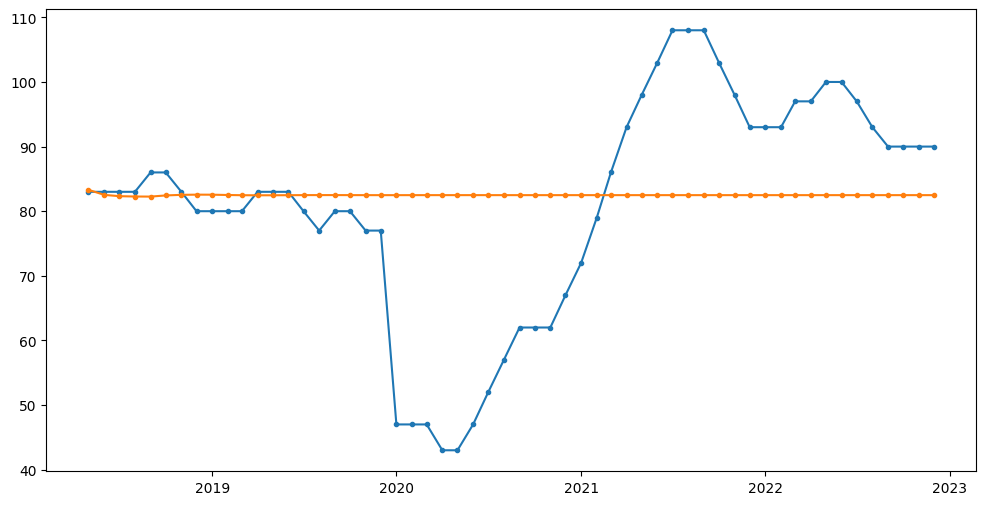

In [ ]:
# 1. Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(df.index[len(train_data):], test_data_original_scale, label='Actual', marker='.')
if arima_predictions is not None:
    plt.plot(df.index[len(train_data):], arima_predictions, label='ARIMA Predicted', marker='.')

In [ ]:
# 2. Lazy Predictor
X = scaled_df.drop(columns=[target_column])
y = scaled_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lazy_regressor = LazyRegressor(verbose=0, ignore_warnings=True, predictions=True)
models, predictions = lazy_regressor.fit(X_train, X_test, y_train, y_test)

print("\nLazy Predictor Models:")
print(models)

100%|██████████| 42/42 [00:11<00:00,  3.69it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2217
[LightGBM] [Info] Number of data points in the train set: 220, number of used features: 44
[LightGBM] [Info] Start training from score 0.533792
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [ ]:
# Function to evaluate performance
def evaluate_model(model, X_test, y_test, scaler, numeric_columns):
    predictions = model.predict(X_test)
    predictions_original_scale = scaler.inverse_transform(np.column_stack([predictions] * len(numeric_columns)))[:, 0]
    y_test_original_scale = scaler.inverse_transform(np.column_stack([y_test] * len(numeric_columns)))[:, 0]
    rmse = np.sqrt(mean_squared_error(y_test_original_scale, predictions_original_scale))
    mae = mean_absolute_error(y_test_original_scale, predictions_original_scale)
    r2 = r2_score(y_test_original_scale, predictions_original_scale)

    print("ARIMA Model Metrics:")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R^2: {r2}")

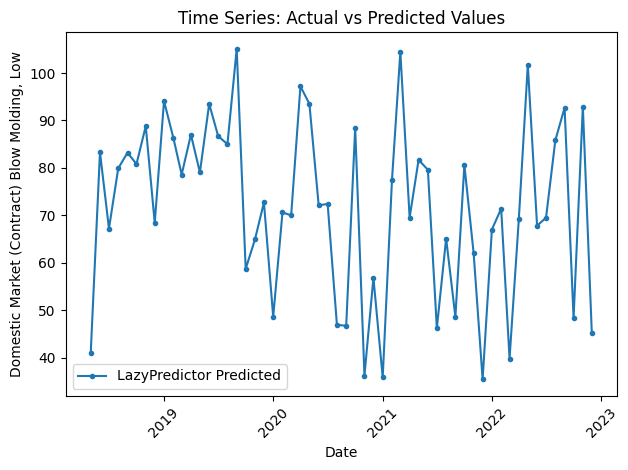

In [ ]:
# Plot Lazy Predictor predictions (taking the first model as an example)
if predictions is not None and len(predictions) > 0:
    lazy_predictions = predictions[models.index[0]]  # Use the first model's predictions
    lazy_predictions_original_scale = scaler.inverse_transform(np.column_stack([lazy_predictions] * len(numeric_columns)))[:, 0]
    plt.plot(df.index[len(train_data):], lazy_predictions_original_scale, label='LazyPredictor Predicted', marker='.')
plt.title('Time Series: Actual vs Predicted Values')
plt.xlabel('Date')
plt.ylabel(target_column)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Prepare data for LSTM
def prepare_data(df, target_column, n_steps):
    X, y = [], []
    target = df[target_column].values
    for i in range(len(df) - n_steps):
        X.append(df.iloc[i:(i + n_steps)].values)
        y.append(target[i + n_steps])
    return np.array(X), np.array(y)


In [ ]:
n_steps = 3  # Number of time steps to look back
X, y = prepare_data(scaled_df, target_column, n_steps)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)


In [ ]:
# LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse')

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)


In [ ]:
# Evaluate the model
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 373ms/step


In [ ]:
# Ensure correct shape for inverse transformation
def inverse_transform_predictions(scaler, X_test, y_pred, y_test):
    original_shape = scaler.data_max_.shape[0]
    extended_pred = np.zeros((y_pred.shape[0], original_shape))
    extended_test = np.zeros((y_test.shape[0], original_shape))
    extended_pred[:, -1] = y_pred[:, 0]
    extended_test[:, -1] = y_test
    y_pred_original_scale = scaler.inverse_transform(extended_pred)[:, -1]
    y_test_original_scale = scaler.inverse_transform(extended_test)[:, -1]
    return y_pred_original_scale, y_test_original_scale

y_pred_original_scale, y_test_original_scale = inverse_transform_predictions(scaler, X_test, y_pred, y_test)


In [ ]:
# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test_original_scale, y_pred_original_scale))
mae = mean_absolute_error(y_test_original_scale, y_pred_original_scale)
r2 = r2_score(y_test_original_scale, y_pred_original_scale)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R^2: {r2}")

RMSE: 5847140.303649349
MAE: 4921170.884947795
R^2: 0.11851617191499442


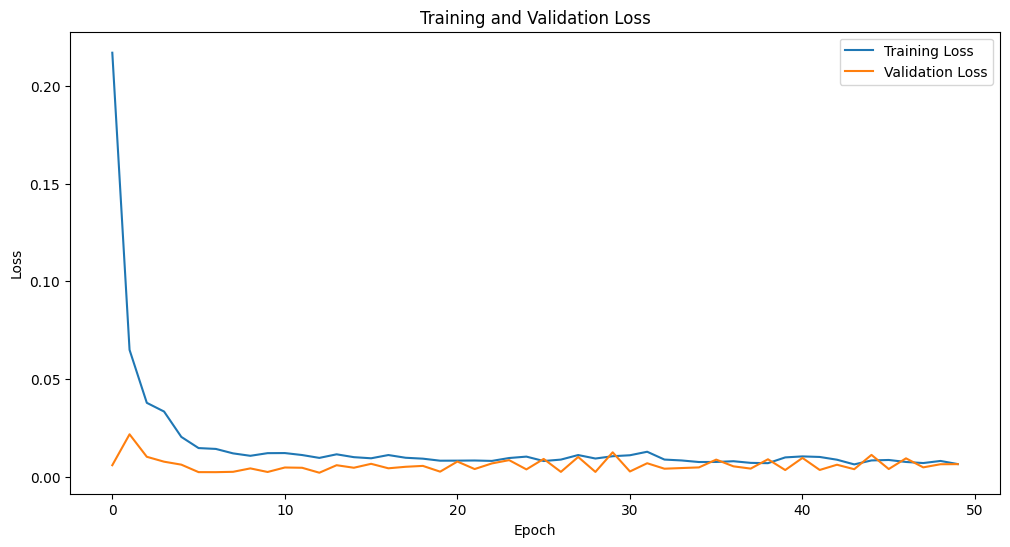

In [ ]:
# 1. Training Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

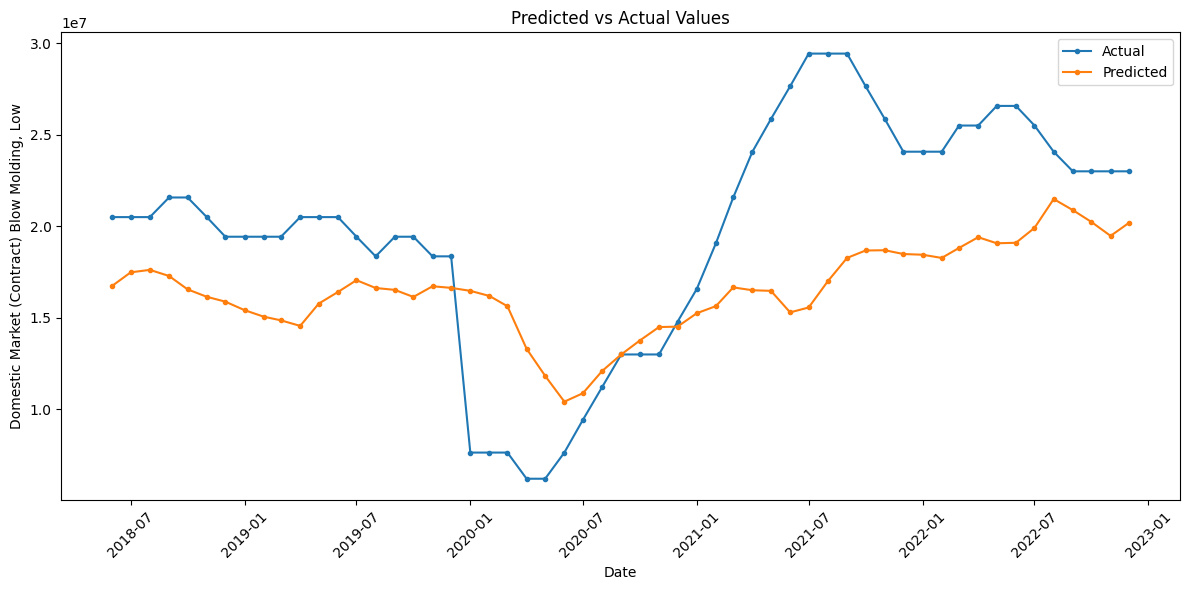

In [ ]:
# 2. Predicted vs Actual Values
plt.figure(figsize=(12, 6))
plt.plot(df.index[len(y_train)+n_steps:], y_test_original_scale, label='Actual', marker='.')
plt.plot(df.index[len(y_train)+n_steps:], y_pred_original_scale, label='Predicted', marker='.')
plt.title('Predicted vs Actual Values')
plt.xlabel('Date')
plt.ylabel(target_column)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
